In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from tqdm import tqdm

# Inställningar
%matplotlib inline
sns.set_theme(style="whitegrid")
tqdm.pandas()


analyzer = SentimentIntensityAnalyzer()
model_name = 'nlptown/bert-base-multilingual-uncased-sentiment'
nlp_worker = pipeline('sentiment-analysis', model=model_name)

# Funktioner
def calculate_vader(text):
    return analyzer.polarity_scores(str(text))['compound']

def calculate_bert(text):
    result = nlp_worker(str(text)[:512])[0]
    stars = int(result['label'].split()[0])
    return 1 if stars >= 4 else -1


df = pd.read_csv('dataset.csv', nrows=50000)
df_clean = df[['review_text', 'review_score']].dropna(subset=['review_text']).drop_duplicates()

print("Data laddad och städad!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6934.90it/s]


Data laddad och städad!


In [14]:
df_pos = df_clean[df_clean['review_score'] == 1].sample(500, random_state=42)
df_neg = df_clean[df_clean['review_score'] == -1].sample(500, random_state=42)
df_vader = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).copy()

print("Analyserar med VADER...")
df_vader['vader_compound'] = df_vader['review_text'].progress_apply(calculate_vader)
df_vader['vader_pred'] = df_vader['vader_compound'].apply(lambda x: 1 if x >= 0.05 else -1)

v_acc = (df_vader['vader_pred'] == df_vader['review_score']).mean()
print(f"VADER Accuracy: {v_acc:.2%}")

Analyserar med VADER...


100%|██████████| 1000/1000 [00:00<00:00, 1997.25it/s]


VADER Accuracy: 63.50%


In [15]:
df_pos_b = df_clean[df_clean['review_score'] == 1].sample(50, random_state=42)
df_neg_b = df_clean[df_clean['review_score'] == -1].sample(50, random_state=42)
df_bert = pd.concat([df_pos_b, df_neg_b]).sample(frac=1, random_state=42).copy()

print("Analyserar med BERT...")
df_bert['bert_pred'] = df_bert['review_text'].progress_apply(calculate_bert)

b_acc = (df_bert['bert_pred'] == df_bert['review_score']).mean()
print(f"BERT Accuracy: {b_acc:.2%}")

Analyserar med BERT...


100%|██████████| 100/100 [00:07<00:00, 12.66it/s]

BERT Accuracy: 85.00%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_20588\2473960516.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette='coolwarm')


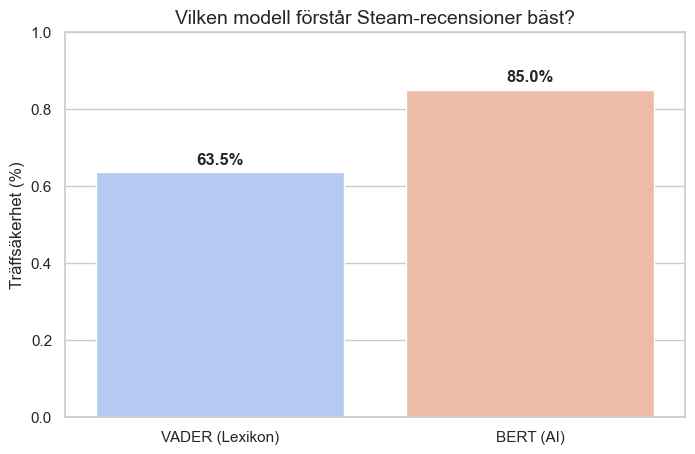

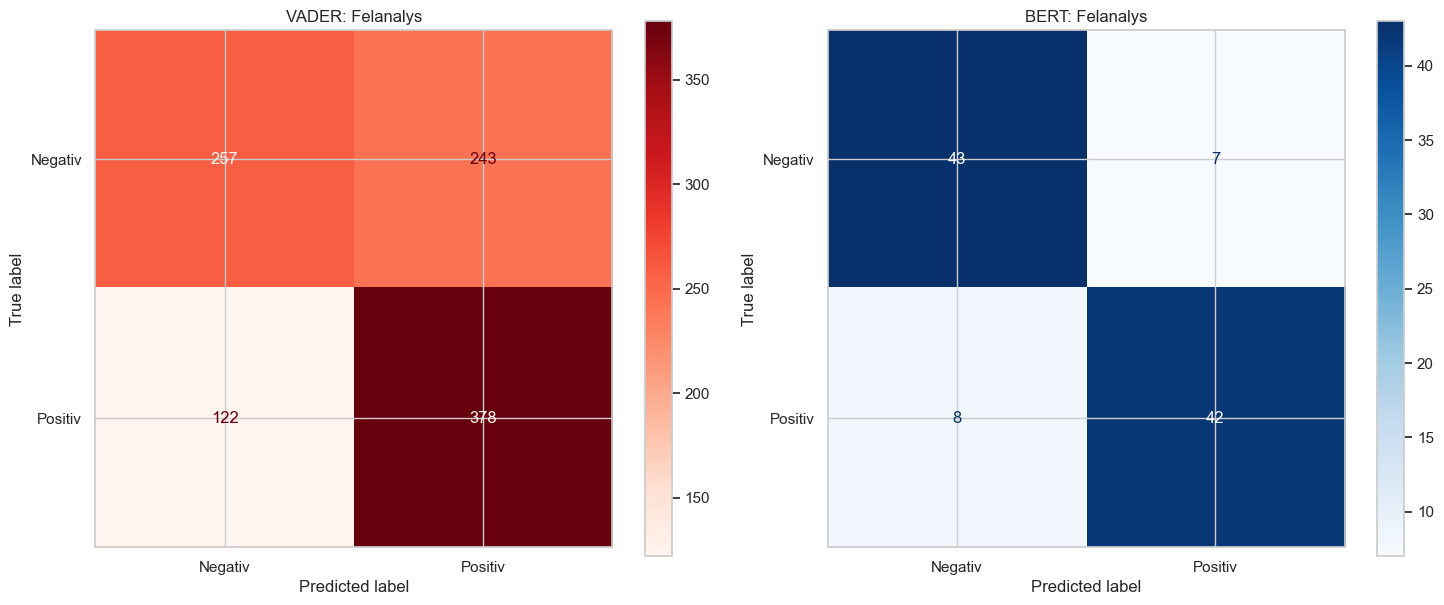

In [ ]:
# --- GRAF 1: Jämförelse av Träffsäkerhet ---
plt.figure(figsize=(8, 5))
models = ['VADER (Lexikon)', 'BERT (AI)']
scores = [v_acc, b_acc]

ax = sns.barplot(x=models, y=scores, palette='coolwarm')
plt.title('Vilken modell förstår Steam-recensioner bäst?', fontsize=14)
plt.ylabel('Träffsäkerhet (%)')
plt.ylim(0, 1)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), 
                ha='center', fontweight='bold')
plt.show()

# --- GRAF 2: Förväxlingsmatriser (Confusion Matrices) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# VADER
ConfusionMatrixDisplay.from_predictions(
    df_vader['review_score'], df_vader['vader_pred'],
    display_labels=['Negativ', 'Positiv'], cmap='Reds', ax=ax1
)
ax1.set_title('VADER: Felanalys', fontsize=12)

# BERT
ConfusionMatrixDisplay.from_predictions(
    df_bert['review_score'], df_bert['bert_pred'],
    display_labels=['Negativ', 'Positiv'], cmap='Blues', ax=ax2
)
ax2.set_title('BERT: Felanalys', fontsize=12)

plt.tight_layout()
plt.show()